# Process the deep mutational scanning data

The data come from the following papers from Yunlong Cao's group:

 - [Imprinted SARS-CoV-2 humoral immunity induces convergent Omicron RBD evolution (2022)](https://www.nature.com/articles/s41586-022-05644-7)
 
 - [Repeated Omicron infection alleviates SARS-CoV-2 immune imprinting (2023)](https://www.biorxiv.org/content/10.1101/2023.05.01.538516v2)

In [1]:
import math
import os

import matplotlib.pyplot as plt

import numpy

import pandas as pd

import yaml



## Process data from [Repeated Omicron infection alleviates SARS-CoV-2 immune imprinting (2023)](https://www.biorxiv.org/content/10.1101/2023.05.01.538516v2)

In [2]:
# read the data
repeated_2023_info = (
    pd.read_csv("Cao_data/SARS-CoV-2-reinfection-DMS/antibody_info.csv")
    .rename(columns={"Unnamed: 0": "antibody"})
).assign(study="repeated_2023")

assert len(repeated_2023_info) == repeated_2023_info["antibody"].nunique()
unique_antibody_list_IC50= repeated_2023_info["antibody"].unique()
repeated_2023_info

,antibody,D614G_IC50,BA1_IC50,BA2_IC50,BA3_IC50,SARS_IC50,BA1_1_IC50,BA2_12_1_IC50,BA2_75_IC50,BA5_IC50,...,BA2_13_IC50,BQ1_1_IC50,XBB_IC50,XBB1_5_IC50,XBB1_5_10_IC50,BA5_ELISA_compete_level,paper_reactivity,source,group,study
0,BD30-604,0.01100,0.28500,0.21900,0.2591,10.0000,0.1983,0.2010,5.9200,6.26000,...,0.1478,10.00000,10.00000,10.00000,10.000000,--,WT,WT convalescents,A1,repeated_2023
1,BD45-21,0.05320,7.12000,8.53000,7.8332,10.0000,6.3242,7.6200,1.7300,7.12000,...,6.9020,10.00000,10.00000,10.00000,10.000000,--,WT,WT convalescents,A1,repeated_2023
2,BD45-70,0.00150,10.00000,0.54300,10.0000,10.0000,10.0000,0.6393,10.0000,0.88900,...,0.5545,10.00000,10.00000,10.00000,10.000000,--,WT,WT convalescents,D2,repeated_2023
3,BD45-105,0.57400,2.56000,2.70000,1.6367,10.0000,2.2312,2.5320,2.1000,2.79000,...,3.0024,1.89000,3.62000,4.81000,NaN,--,WT,WT convalescents,E3,repeated_2023
4,BD45-145,0.00540,0.06280,0.79200,1.2896,1.1641,0.8429,0.7325,10.0000,0.70400,...,NaN,10.00000,10.00000,10.00000,10.000000,--,WT,WT convalescents,D3,repeated_2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345,SN1854,0.00375,0.00108,0.00296,NaN,10.0000,NaN,NaN,0.0023,0.00133,...,NaN,0.00221,0.00891,0.00886,0.005237,0.90387421,cross,BA.2 convalescents,A1,repeated_2023
1346,SN1867,0.09070,0.05500,6.48000,NaN,NaN,NaN,NaN,2.4700,0.18800,...,NaN,0.23800,0.17900,0.38500,NaN,0.863914622,cross,BA.2 convalescents,F1,repeated_2023
1347,SN1884,0.10300,NaN,0.40700,NaN,NaN,NaN,NaN,0.5750,0.31800,...,NaN,0.66500,0.47300,1.06000,NaN,0.726595079,cross,BA.2 convalescents,F1,repeated_2023
1348,SN1926,0.08500,0.03540,0.04760,NaN,10.0000,NaN,NaN,0.0383,0.02080,...,NaN,0.10500,0.12400,0.23600,NaN,0.740049921,cross,BA.2 convalescents,A1,repeated_2023


In [3]:
# get the antibody sources
repeated_2023_source = (
    repeated_2023_info
    [["antibody", "source", "study"]]
    .query("source != 'WT mouse'")  # do not keep mouse antibodies
)

print("Number of antibodies from each source:")
display(
    repeated_2023_source
    .groupby(["study", "source"])
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "nunique"))
    .sort_values("n_antibodies", ascending=False)
)

Number of antibodies from each source:


n_antibodies
study         source                                      
repeated_2023 BA.5 convalescents                       445
              BA.1 convalescents reinfection           284
              BF.7 convalescents                       243
              BA.2 convalescents reinfection           232
              BA.2 convalescents                        53
              long-term BA.1 convalescents              38
              BA.1 convalescents                        36
              WT convalescents                          12
              SARS convalescents                         5

In [4]:
# get the IC50s
repeated_2023_ic50s = (
    repeated_2023_info
    .melt(
        id_vars=["study", "antibody"],
        value_vars=[c for c in repeated_2023_info if c.endswith("_IC50")],
        var_name="virus",
        value_name="IC50",
    )
    .query("IC50.notnull()")  # no data, 10 means non-neutralizing
    .assign(
        virus=lambda x: x["virus"].str.replace("_IC50", "").map({
            "D614G": "D614G",
            "BA1": "BA.1",
            "BA2": "BA.2",
            "BA3": "BA.3",
            "SARS": "SARS",
            "BA1_1": "BA.1.1",
            "BA2_12_1": "BA.2.12.1",
            "BA2_75": "BA.2.75",
            "BA5": "BA.5",
            "BF7": "BF.7",
            "BA2_13": "BA.2.13",
            "BQ1_1": "BQ.1.1",
            "XBB": "XBB",
            "XBB1_5": "XBB.1.5",
            "XBB1_5_10": "XBB.1.5.10",
        }),
    )
)

print("\nNumber of IC50s per antibody:")
display(
    repeated_2023_ic50s
    .groupby("antibody", as_index=False)
    .aggregate(viruses_w_IC50s=pd.NamedAgg("virus", lambda s: "; ".join(s)))
    .groupby("viruses_w_IC50s")
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "nunique"))
    .sort_values("n_antibodies", ascending=False)
)
repeated_2023_ic50s


Number of IC50s per antibody:


,n_antibodies
viruses_w_IC50s,
D614G; BA.1; BA.2; SARS; BA.2.75; BA.5; BF.7; BQ.1.1; XBB; XBB.1.5; XBB.1.5.10,428
D614G; BA.1; BA.2; SARS; BA.2.75; BA.5; BF.7; BQ.1.1; XBB; XBB.1.5,181
D614G; BA.1; BA.2; BA.3; SARS; BA.1.1; BA.2.12.1; BA.2.75; BA.5; BA.2.13; BQ.1.1; XBB; XBB.1.5; XBB.1.5.10,137
D614G; BA.1; BA.2; SARS; BA.2.75; BA.5; BQ.1.1; XBB; XBB.1.5; XBB.1.5.10,130
D614G; BA.1; BA.2; BA.2.75; BA.5; BF.7; BQ.1.1; XBB; XBB.1.5; XBB.1.5.10,129
D614G; BA.1; BA.2; SARS; BA.2.75; BA.5; BQ.1.1; XBB; XBB.1.5,92
D614G; BA.1; BA.2; BA.2.75; BA.5; BQ.1.1; XBB; XBB.1.5,48
D614G; SARS; BA.5; BQ.1.1; XBB; XBB.1.5; XBB.1.5.10,42
D614G; BA.1; BA.2; BA.2.75; BA.5; BQ.1.1; XBB; XBB.1.5; XBB.1.5.10,34


,study,antibody,virus,IC50
0,repeated_2023,BD30-604,D614G,0.011000
1,repeated_2023,BD45-21,D614G,0.053200
2,repeated_2023,BD45-70,D614G,0.001500
3,repeated_2023,BD45-105,D614G,0.574000
4,repeated_2023,BD45-145,D614G,0.005400
...,...,...,...,...
20217,repeated_2023,SN1302,XBB.1.5.10,0.008232
20227,repeated_2023,SN1379,XBB.1.5.10,10.000000
20232,repeated_2023,SN1461,XBB.1.5.10,10.000000
20244,repeated_2023,SN1851,XBB.1.5.10,0.155200


In [5]:
# get the binding reactivities
repeated_2023_binding = (
    repeated_2023_info
    .query("paper_reactivity != '--'")
    .assign(
        binds=lambda x: x["paper_reactivity"].map(
            {
                "WT": ["Wuhan-Hu-1"],
                "cross": ["Wuhan-Hu-1", "Omicron BA.2/BA.5"],
                "specific": ["Omicron BA.2/BA.5"],
            }
        )
    )
    [["study", "antibody", "binds"]]
    .explode("binds")
)

print("\nBinding targets per antibody:")
display(
    repeated_2023_binding
    .groupby("antibody", as_index=False)
    .aggregate(binds=pd.NamedAgg("binds", lambda s: "; ".join(s)))
    .groupby("binds")
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "nunique"))
    .sort_values("n_antibodies", ascending=False)
)
repeated_2023_binding


Binding targets per antibody:


,n_antibodies
binds,
Wuhan-Hu-1; Omicron BA.2/BA.5,768
Omicron BA.2/BA.5,562
Wuhan-Hu-1,19


,study,antibody,binds
0,repeated_2023,BD30-604,Wuhan-Hu-1
1,repeated_2023,BD45-21,Wuhan-Hu-1
2,repeated_2023,BD45-70,Wuhan-Hu-1
3,repeated_2023,BD45-105,Wuhan-Hu-1
4,repeated_2023,BD45-145,Wuhan-Hu-1
...,...,...,...
1347,repeated_2023,SN1884,Omicron BA.2/BA.5
1348,repeated_2023,SN1926,Wuhan-Hu-1
1348,repeated_2023,SN1926,Omicron BA.2/BA.5
1349,repeated_2023,SN1932,Wuhan-Hu-1


Now read the actual escape data:

In [6]:
repeated_2023_escape = (
    pd.read_csv("Cao_data/SARS-CoV-2-reinfection-DMS/antibody_dms_merge_clean.csv.gz")
   
    .assign(study="repeated_2023")
)
unique_antibody_list = repeated_2023_escape.antibody.unique()
print("Number of antibodies in the escape data:", len(unique_antibody_list))
repeated_2023_escape.sort_values("antibody")

Number of antibodies in the escape data: 1350


,site,wildtype,mutation,mut_escape,antibody,group,study
7223,456,F,G,0.997917,BD30-604,A.489,repeated_2023
7209,455,L,A,0.994093,BD30-604,A.489,repeated_2023
7208,453,Y,W,0.074000,BD30-604,A.489,repeated_2023
7207,453,Y,S,0.052352,BD30-604,A.489,repeated_2023
7206,453,Y,Q,0.032495,BD30-604,A.489,repeated_2023
...,...,...,...,...,...,...,...
65920,430,T,N,0.135907,SN1932,A.489,repeated_2023
65921,430,T,Y,0.150316,SN1932,A.489,repeated_2023
65922,439,N,D,0.193429,SN1932,A.489,repeated_2023
65913,420,D,R,0.149284,SN1932,A.489,repeated_2023


## Process data from [Imprinted SARS-CoV-2 humoral immunity induces convergent Omicron RBD evolution (2022)](https://www.nature.com/articles/s41586-022-05644-7)

In [7]:
# read the data, which is in multiple sheets
imprinted_2022_raw_info = pd.read_excel(
    "Cao_data/convergent_RBD_evolution/antibody_info.xlsx",
    header=1,
    sheet_name=None,
    usecols=lambda c: not c.startswith("Unnamed"),
)

common_cols = None

for sheetname, sheet in imprinted_2022_raw_info.items():
    columns = sheet.columns.tolist()
    if common_cols is None:
        common_cols = columns
    else:
        common_cols = [
            c for c in columns if c in set(common_cols).intersection(columns)
        ]

imprinted_2022_info = pd.concat(
    [
        sheet[common_cols].assign(sheet_name=sheet_name)
        for sheet_name, sheet in imprinted_2022_raw_info.items()
    ],
    ignore_index=True,
).rename(columns={"Antibody  Name": "antibody"}).assign(study="imprinted_2022")

assert len(imprinted_2022_info) == imprinted_2022_info["antibody"].nunique()
imprinted_2022_info

,antibody,source,D614G,BA.1,BA.2,BA.5,BA.2.75,BQ.1.1,XBB,Heavy chain V gene,Heavy chain J gene,Light chain V gene,Light chain J gene,Heavy chain AA,Light chain AA,sheet_name,study
0,BD-196,WT convalescents,1.93,>10,>10,>10,>10,>10,>10,IGHV1-3,IGHJ6,IGKV2-58,IGKJ1,QVQLVQSGAEVKKPGASVKVSCKASGYTFTSYAMHWVRQAPGQRLE...,DVVMTQSPLSLPVTLGQPASISCRSSQSLVYSDGNTYLNWFQQRPG...,cross,imprinted_2022
1,BD-218,WT convalescents,0.0104,0.00849,0.00937,5.26,0.0116,>10,>10,IGHV4-34,IGHJ1,IGKV3-11,IGKJ5,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSDYFWYWIRQPPGKGLE...,EIVLTQSPATLSLSPGERATLSCRASQSVSSYLAWYQQKPGQAPRL...,cross,imprinted_2022
2,BD-236,WT convalescents,0.0173,>10,>10,>10,>10,>10,>10,IGHV3-53,IGHJ6,IGKV1-9,IGKJ4,EVQLVESGGGLIQPGGSLRLSCAASGITVSSNYMSWVRQAPGKGLE...,IQLTQSPSSLSASVGDRVTITCRASQGISSYLAWYQQKPGKAPKLL...,cross,imprinted_2022
3,BD-254,WT convalescents,0.25,>10,>10,>10,>10,>10,>10,IGHV3-23,IGHJ4,IGLV7-46,IGLJ2,EVQLLESGGGLVQPGGSLRLSCAASGFTLSSYAMSWVRQAPGRGLE...,QAVVTQEPSLTVSPGGTVTLTCGSSTGAVTSGHYPYWFQQKPGQAP...,cross,imprinted_2022
4,BD-255,WT convalescents,0.113,>10,>10,>10,>10,>10,>10,IGHV3-30,IGHJ6,IGKV3-15,IGKJ2,QVQLVESGGGVVQPGRSLRLSCVASGFTFSNYDMHWVRQAPGKGLE...,EIVMTQSPAILSVSPGERATLSCRASQSVTRNLAWYQQKPGQAPRL...,cross,imprinted_2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,BD57-0308,BA.5 convalescents,>10,>10,>10,>10,>10,>10,>10,IGHV3-30,IGHJ6,IGKV4-1,IGKJ1,QVQLVESGGGVVQPGRSLRLSCAASGFSFSNYAMHWVRQAPGKGLE...,DIVMTQSPDSLAVSLGERATINCKSSQSVFYSSRDKNYVAWYQQQP...,specific,imprinted_2022
3329,BD57-0318,BA.5 convalescents,>10,>10,>10,>10,>10,>10,>10,IGHV2-5,IGHJ4,IGKV3-15,IGKJ3,QITLKESGPTLVKPTQTLTLTCTFSGFSLSTSGVGVGWIRQPPGKA...,ERVMTQSPATMSVSPGERATLSCRASQSVSSNLAWYQQKPGQAPRL...,specific,imprinted_2022
3330,BD57-0332,BA.5 convalescents,>10,>10,>10,>10,>10,>10,>10,IGHV4-39,IGHJ5,IGKV1D-12,IGKJ4,QLQLQESGPGLVKPSATLSLTCNVSGGSISSSIYWWAWIRQSPGMG...,DIHMTQSPSSVSASVGDRVTITCRASQALSSWLAWYQQRPGKPPTL...,specific,imprinted_2022
3331,BD57-0382,BA.5 convalescents,>10,>10,>10,>10,>10,>10,>10,IGHV5-51,IGHJ4,IGLV2-11,IGLJ3,EVQLVQSGADVKKPGESLRISCKGSGYTFTNYWIAWVRLMPGKGLE...,HSALTQPRTVSGSLGQSVTISCTGTSSNVGFNNHVSWYQLRPGKVP...,specific,imprinted_2022


In [8]:
# get the antibody sources
imprinted_2022_source = (
    imprinted_2022_info
    [["antibody", "source", "study"]]
    .query("source != 'WT-engineered'")
)

display(
    imprinted_2022_source
    .groupby(["study", "source"])
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "nunique"))
)

n_antibodies
study          source                          
imprinted_2022 BA.1 convalescents           752
               BA.2 convalescents           751
               BA.5 convalescents           269
               SARS convalescents           881
               WT convalescents             438
               WT vaccinees                 240

In [9]:
# get the IC50s
imprinted_2022_ic50s = (
    imprinted_2022_info
    .melt(
        id_vars=["study", "antibody"],
        value_vars=["D614G", "BA.1", "BA.2", "BA.5", "BA.2.75", "BQ.1.1", "XBB"],
        var_name="virus",
        value_name="IC50",
    )
    # values of >10 to 10
    .query("IC50 != '--'")
    .assign(IC50=lambda x: x["IC50"].map(lambda ic50: 10 if ic50 == ">10" else float(ic50)))
)

print("\nNumber of IC50s per antibody:")
display(
    imprinted_2022_ic50s
    .groupby("antibody", as_index=False)
    .aggregate(viruses_w_IC50s=pd.NamedAgg("virus", lambda s: "; ".join(s)))
    .groupby("viruses_w_IC50s")
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "nunique"))
    .sort_values("n_antibodies", ascending=False)
)
imprinted_2022_ic50s


Number of IC50s per antibody:


,n_antibodies
viruses_w_IC50s,
D614G; BA.1; BA.2; BA.5; BA.2.75; BQ.1.1; XBB,3309
D614G; BA.1; BA.2; BA.5; BA.2.75,13
D614G; BA.1; BA.2; BA.5; BA.2.75; BQ.1.1,3
D614G; BA.1; BA.2; BA.5; BA.2.75; XBB,3
BQ.1.1; XBB,2
BA.1; BA.2; BA.5; BA.2.75; BQ.1.1; XBB,1
BA.1; BQ.1.1; XBB,1
D614G; BQ.1.1; XBB,1


,study,antibody,virus,IC50
0,imprinted_2022,BD-196,D614G,1.9300
1,imprinted_2022,BD-218,D614G,0.0104
2,imprinted_2022,BD-236,D614G,0.0173
3,imprinted_2022,BD-254,D614G,0.2500
4,imprinted_2022,BD-255,D614G,0.1130
...,...,...,...,...
23326,imprinted_2022,BD57-0308,XBB,10.0000
23327,imprinted_2022,BD57-0318,XBB,10.0000
23328,imprinted_2022,BD57-0332,XBB,10.0000
23329,imprinted_2022,BD57-0382,XBB,10.0000


In [10]:
# get the binding reactivities
imprinted_2022_binding = (
    imprinted_2022_info
    .assign(
        binds=lambda x: x["sheet_name"].map(
            {
                "cross": ["Wuhan-Hu-1", "Omicron BA.2/BA.5"],
                "specific": ["Omicron BA.2/BA.5"],
            }
        )
    )
    [["study", "antibody", "binds"]]
    .explode("binds")
)

print("\nBinding targets per antibody:")
display(
    imprinted_2022_binding
    .groupby("antibody", as_index=False)
    .aggregate(binds=pd.NamedAgg("binds", lambda s: "; ".join(s)))
    .groupby("binds")
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "nunique"))
    .sort_values("n_antibodies", ascending=False)
)
imprinted_2022_binding


Binding targets per antibody:


,n_antibodies
binds,
Wuhan-Hu-1; Omicron BA.2/BA.5,3051
Omicron BA.2/BA.5,282


,study,antibody,binds
0,imprinted_2022,BD-196,Wuhan-Hu-1
0,imprinted_2022,BD-196,Omicron BA.2/BA.5
1,imprinted_2022,BD-218,Wuhan-Hu-1
1,imprinted_2022,BD-218,Omicron BA.2/BA.5
2,imprinted_2022,BD-236,Wuhan-Hu-1
...,...,...,...
3328,imprinted_2022,BD57-0308,Omicron BA.2/BA.5
3329,imprinted_2022,BD57-0318,Omicron BA.2/BA.5
3330,imprinted_2022,BD57-0332,Omicron BA.2/BA.5
3331,imprinted_2022,BD57-0382,Omicron BA.2/BA.5


Now read the actual escape data:

In [11]:
imprinted_2022_escape = (
    pd.read_csv("Cao_data/convergent_RBD_evolution/use_res_clean.csv")

    .assign(study="imprinted_2022")
)

imprinted_2022_escape

,antibody,site,mutation,mut_escape,group,study
0,BD-196,349,H,0.208866,C,imprinted_2022
1,BD-196,349,N,0.065818,C,imprinted_2022
2,BD-196,349,P,0.128169,C,imprinted_2022
3,BD-196,351,H,0.298263,C,imprinted_2022
4,BD-196,352,G,0.071541,C,imprinted_2022
...,...,...,...,...,...,...
341767,XGv-422,514,F,0.016126,E3,imprinted_2022
341768,XGv-422,514,I,0.023972,E3,imprinted_2022
341769,XGv-422,514,M,0.057837,E3,imprinted_2022
341770,XGv-422,514,R,0.020084,E3,imprinted_2022


## Aggregate the antibody information from the different studies

First, read the information on duplicated antibodies to get duplicate names:

In [12]:
antibody_renaming = (
    pd.read_excel("Cao_data/all-repo-duplicates.xlsx")
    .set_index("Antibody  Name")
    ["BD equivalent name"]
    .to_dict()
)
antibody_renaming

{'BD30-604': 'BD30-604',
 'DXP-604': 'BD30-604',
 'BD45-105': 'BD45-105',
 'S2H97': 'BD45-105',
 'BD45-145': 'BD45-145',
 'C576': 'BD45-145',
 'BD45-147': 'BD45-147',
 'C581': 'BD45-147',
 'BD45-152': 'BD45-152',
 'LY-CoV1404': 'BD45-152',
 'BD45-158': 'BD45-158',
 'Ehling_mAb-50': 'BD45-158',
 'BD45-21': 'BD45-21',
 'BRII-196': 'BD45-21',
 'BD45-228': 'BD45-228',
 'COV2-2046': 'BD45-228',
 'BD45-231': 'BD45-231',
 'COV2-2068': 'BD45-231',
 'BD45-277': 'BD45-277',
 'COV2-2258': 'BD45-277',
 'BD45-70': 'BD45-70',
 'BG7-15': 'BD45-70',
 'BD55-1205': 'BD55-1205',
 'BD55-3372': 'BD55-3372',
 'BD55-4637': 'BD55-4637',
 'BD55-5483': 'BD55-5483',
 'BD55-5514': 'BD55-5514',
 'BD55-5840': 'BD55-5840',
 'BD56-004': 'BD56-004',
 'SN0004': 'BD56-004',
 'BD56-096': 'BD56-096',
 'SN0096': 'BD56-096',
 'BD56-1180': 'BD56-1180',
 'SN1180': 'BD56-1180',
 'BD56-1183': 'BD56-1183',
 'SN1183': 'BD56-1183',
 'BD56-1192': 'BD56-1192',
 'SN1192': 'BD56-1192',
 'BD56-1198': 'BD56-1198',
 'SN1198': 'BD56-1198'

Now aggregate the antibody sources:

In [13]:
antibody_source = (
    pd.concat(
        [repeated_2023_source, imprinted_2022_source],
        ignore_index=True,
    )
    .assign(
        antibody=lambda x: x["antibody"].map(
            lambda a: antibody_renaming[a] if a in antibody_renaming else a
        ),
    )
)

assert (
    antibody_source["antibody"].nunique()
    == len(antibody_source[["antibody", "source"]].drop_duplicates())
)

print("Dropping the following antibodies duplicated across studies:")
display(antibody_source.groupby("antibody").tail(-1).reset_index(drop=True))

# keep just one of antibodies repeated across studies
antibody_source = antibody_source.groupby("antibody").first().reset_index()
#save in processed_cao_data

print("\nRetained sources:")
display(antibody_source)


Dropping the following antibodies duplicated across studies:


,antibody,source,study
0,BD30-604,WT convalescents,imprinted_2022
1,BD45-105,WT convalescents,imprinted_2022
2,BD45-145,WT convalescents,imprinted_2022
3,BD45-147,WT convalescents,imprinted_2022
4,BD45-152,WT convalescents,imprinted_2022
...,...,...,...
297,BD57-0300,BA.5 convalescents,imprinted_2022
298,BD57-0308,BA.5 convalescents,imprinted_2022
299,BD57-0318,BA.5 convalescents,imprinted_2022
300,BD57-0332,BA.5 convalescents,imprinted_2022



Retained sources:


,antibody,source,study
0,1-57,WT convalescents,imprinted_2022
1,2-15,WT convalescents,imprinted_2022
2,7D6,WT convalescents,imprinted_2022
3,ADG-2,SARS convalescents,imprinted_2022
4,B38,WT convalescents,imprinted_2022
...,...,...,...
4372,XGv-416,WT vaccinees,imprinted_2022
4373,XGv-418,WT vaccinees,imprinted_2022
4374,XGv-420,WT vaccinees,imprinted_2022
4375,XGv-421,WT vaccinees,imprinted_2022


Now the IC50s:

In [14]:
antibody_ic50s = (
    pd.concat(
        [repeated_2023_ic50s, imprinted_2022_ic50s],
        ignore_index=True,
    )
    .assign(
        antibody=lambda x: x["antibody"].map(
            lambda a: antibody_renaming[a] if a in antibody_renaming else a
        ),
    )
)
print("lines in antibody_ic50s:", len(antibody_ic50s))

#remove duplicates
antibody_ic50s = antibody_ic50s.drop_duplicates(subset=["IC50", "antibody", "virus"])
#assign study of antibody_source for each antibody
antibody_ic50s['study']=antibody_ic50s.antibody.map(antibody_source.set_index('antibody').study)
#save in processed_cao_data folder
print("remaining lines in antibody_ic50s:", len(antibody_ic50s))

antibody_ic50s

lines in antibody_ic50s: 37227
remaining lines in antibody_ic50s: 35138


,study,antibody,virus,IC50
0,repeated_2023,BD30-604,D614G,0.0110
1,repeated_2023,BD45-21,D614G,0.0532
2,repeated_2023,BD45-70,D614G,0.0015
3,repeated_2023,BD45-105,D614G,0.5740
4,repeated_2023,BD45-145,D614G,0.0054
...,...,...,...,...
37194,imprinted_2022,BD56-1496,XBB,10.0000
37195,imprinted_2022,BD56-1498,XBB,10.0000
37204,imprinted_2022,BD57-0278,XBB,10.0000
37219,imprinted_2022,BD57-0276,XBB,10.0000


Now the binding targets:

In [15]:
antibody_binding = (
    pd.concat(
        [repeated_2023_binding, imprinted_2022_binding],
        ignore_index=True,
    )
    .assign(
        antibody=lambda x: x["antibody"].map(
            lambda a: antibody_renaming[a] if a in antibody_renaming else a
        ),
    )
)

print("Dropping the following binding duplicated across studies:")
display(antibody_binding.groupby(["antibody", "binds"]).tail(-1).reset_index(drop=True))

# keep just one of binding repeated across studies
antibody_binding = antibody_binding.groupby(["antibody", "binds"]).first().reset_index()

print("\nBinding summary:")
assert antibody_binding["binds"].notnull().all()
display(
    antibody_binding
    .groupby("antibody", as_index=False)
    .aggregate({"binds": lambda s: "; ".join(s)})
    .groupby("binds")
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "nunique"))
)

#remove duplicates
antibody_binding = antibody_binding.drop_duplicates(subset=["antibody", "binds"])
antibody_binding['study']=antibody_binding.antibody.map(antibody_source.set_index('antibody').study)

#save in processed_cao_data folder
antibody_binding

Dropping the following binding duplicated across studies:


,study,antibody,binds
0,imprinted_2022,BD30-604,Wuhan-Hu-1
1,imprinted_2022,BD45-105,Wuhan-Hu-1
2,imprinted_2022,BD45-145,Wuhan-Hu-1
3,imprinted_2022,BD45-147,Wuhan-Hu-1
4,imprinted_2022,BD45-152,Wuhan-Hu-1
...,...,...,...
542,imprinted_2022,BD57-0300,Omicron BA.2/BA.5
543,imprinted_2022,BD57-0308,Omicron BA.2/BA.5
544,imprinted_2022,BD57-0318,Omicron BA.2/BA.5
545,imprinted_2022,BD57-0332,Omicron BA.2/BA.5



Binding summary:


,n_antibodies
binds,
Omicron BA.2/BA.5,804
Omicron BA.2/BA.5; Wuhan-Hu-1,3574
Wuhan-Hu-1,2


,antibody,binds,study
0,1-57,Omicron BA.2/BA.5,imprinted_2022
1,1-57,Wuhan-Hu-1,imprinted_2022
2,2-15,Omicron BA.2/BA.5,imprinted_2022
3,2-15,Wuhan-Hu-1,imprinted_2022
4,7D6,Omicron BA.2/BA.5,imprinted_2022
...,...,...,...
7949,XGv-420,Wuhan-Hu-1,imprinted_2022
7950,XGv-421,Omicron BA.2/BA.5,imprinted_2022
7951,XGv-421,Wuhan-Hu-1,imprinted_2022
7952,XGv-422,Omicron BA.2/BA.5,imprinted_2022


Now combine the escape data, keeping only the escape data in the antibody source data frame for that study.
We normalize so that the max site escape for each antibody is 1.
We also determine how many sites have significant escape, and drop antibodies with too many such sites:

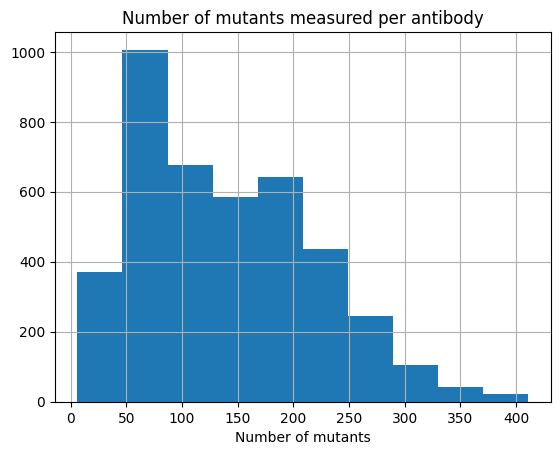

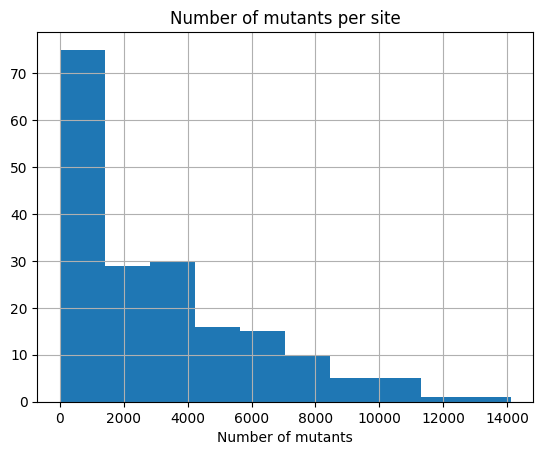

,site,wildtype,mutation,mut_escape,antibody,group,study
0,337,P,A,0.343466,BD55-5840,D2.440,repeated_2023
1,337,P,C,0.516024,BD55-5840,D2.440,repeated_2023
2,337,P,D,0.424783,BD55-5840,D2.440,repeated_2023
3,337,P,E,0.343645,BD55-5840,D2.440,repeated_2023
4,337,P,G,0.684919,BD55-5840,D2.440,repeated_2023
...,...,...,...,...,...,...,...
577346,514,NaN,F,0.016126,XGv-422,E3,imprinted_2022
577347,514,NaN,I,0.023972,XGv-422,E3,imprinted_2022
577348,514,NaN,M,0.057837,XGv-422,E3,imprinted_2022
577349,514,NaN,R,0.020084,XGv-422,E3,imprinted_2022


In [16]:
escape = (
    pd.concat(
        [
            # get just antibodies from that study
            (
                escape_df
                .assign(
                    antibody=lambda x: x["antibody"].map(
                        lambda a: antibody_renaming[a] if a in antibody_renaming else a
                    ),
                )
                .merge(antibody_source.query("study == @study")[["antibody"]])
            )
            for study, escape_df in [
                ("repeated_2023", repeated_2023_escape),
                ("imprinted_2022", imprinted_2022_escape),
            ]
        ],
        ignore_index=True,
    )

)

#plot histogram of  row number per unique site
escape.groupby('antibody').size().hist()
#title
plt.title('Number of mutants measured per antibody')
#x axis: nb of mutants
plt.xlabel('Number of mutants')
plt.show()
escape.groupby('site').size().hist()
#title
plt.title('Number of mutants per site')
#x axis: nb of mutants
plt.xlabel('Number of mutants')
plt.show()
escape

In [17]:

escape.query('antibody=="BD55-5840"')

,site,wildtype,mutation,mut_escape,antibody,group,study
0,337,P,A,0.343466,BD55-5840,D2.440,repeated_2023
1,337,P,C,0.516024,BD55-5840,D2.440,repeated_2023
2,337,P,D,0.424783,BD55-5840,D2.440,repeated_2023
3,337,P,E,0.343645,BD55-5840,D2.440,repeated_2023
4,337,P,G,0.684919,BD55-5840,D2.440,repeated_2023
...,...,...,...,...,...,...,...
210,526,G,Q,0.415514,BD55-5840,D2.440,repeated_2023
211,526,G,R,0.242393,BD55-5840,D2.440,repeated_2023
212,526,G,T,0.304149,BD55-5840,D2.440,repeated_2023
213,526,G,V,0.148185,BD55-5840,D2.440,repeated_2023


Only keep the antibodies that have all types of measurements when writing files in next cell:

In [18]:
antibodies = (
    antibody_source
    [["antibody"]]
    .assign(has_source=True)
    .drop_duplicates()
    .merge(
        antibody_ic50s[["antibody"]].assign(has_ic50=True).drop_duplicates(),
        how="outer",
        validate="one_to_one",
    )
    .merge(
        antibody_binding[["antibody"]].assign(has_binding=True).drop_duplicates(),
        how="outer",
        validate="one_to_one",
    )
    .merge(
        escape[["antibody"]].assign(has_escape=True).drop_duplicates(),
        how="outer",
        validate="one_to_one",
    )
    .set_index("antibody")
    .fillna(False)
    .assign(has_all=lambda x: x.all(axis=1))
    .reset_index()
)

print("This many antibodies have all measurements:")
display(
    antibodies
    .groupby([c for c in antibodies.columns if c != "antibody"])
    .aggregate(n_antibodies=pd.NamedAgg("antibody", "count"))
)

antibodies_to_keep = set(antibodies.query("has_all")["antibody"])

This many antibodies have all measurements:


C:\Users\maria\AppData\Local\Temp\ipykernel_9932\1267495770.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


n_antibodies
has_source has_ic50 has_binding has_escape has_all              
False      True     True        False      False               4
True       True     False       True       False               1
                    True        False      False             246
                                True       True             4130

Write the output files, only with antibodies to keep:

In [19]:
os.makedirs("results", exist_ok=True)

(
    antibody_source
    .query("antibody in @antibodies_to_keep")
    .to_csv("results/antibody_sources.csv", index=False)
)

(
    antibody_ic50s
    .query("antibody in @antibodies_to_keep")
    .drop(columns="study")
    .to_csv("results/antibody_IC50s.csv", index=False)
)

(
    antibody_binding
    .query("antibody in @antibodies_to_keep")
    .drop(columns="study")
    .to_csv("results/antibody_binding.csv", index=False)
)

(
    escape
    .query("antibody in @antibodies_to_keep")
    .to_csv("results/escape.csv", float_format="%.4g", index=False)
)

